# How it works

Below are a series of examples to verify the correct functioning of the MadridFines, Cache, and CacheUrl classes.

#### Generate distribution archives

```
python3 -m pip install --upgrade build

# Now run this command from the same directory where pyproject.toml is located:
python3 -m build

```


#### Install the new Python package.

```
python3 -m pip install dist/madridfinesmanager-0.0.1-py3-none-any.whl
```



#### Import the classes and libraries required for the following examples.

In [1]:
from traffic_fines import *
from pathlib import Path

# CacheUrl

Create a new instance of the CacheUrl class

In [3]:
app_name = "test_madrid_fines"
obsolescence = 10 # 10 days of validity for the files in the cache
cache_url = CacheUrl(app_name, obsolescence)

In addition to the `app_name` and `obsolescence` parameters, we can also pass the `cache_dir` parameter to explicitly specify the directory where the cached files will be stored.

If this parameter is not provided, as in the example shown above, a new folder will be created in the user’s root directory, and that path (plus `/{app_name}`) will be stored in the `cache_dir` property.

In [4]:
print(cache_url.cache_dir)

/Users/daniel/.my_cache/test_madrid_fines


When making a web request with `get`, the result is stored in the cache while also being returned as the response.

If the request returns a status code other than `200`, an exception is raised, as shown in the example below.

```CacheError: url: https://www.google.com/404 returned status code 404```

In [5]:
cache_url.get("https://www.google.com/404")

CacheError: url: https://www.google.com/404 returned status code 404

Now let's see a successful case, where we receive a `200` response status.

In [6]:
python_docs_url = "https://docs.python.org/"
content = cache_url.get(python_docs_url)
content

'<!DOCTYPE html>\n\n<html lang="en" data-content_root="./">\n  <head>\n    <meta charset="utf-8" />\n    <meta name="viewport" content="width=device-width, initial-scale=1.0" /><title>3.14.5 Documentation</title><meta name="viewport" content="width=device-width, initial-scale=1.0">\n    \n    <link rel="stylesheet" type="text/css" href="_static/pygments.css?v=b86133f3" />\n    <link rel="stylesheet" type="text/css" href="_static/classic.css?v=234b1a7c" />\n    <link rel="stylesheet" type="text/css" href="_static/pydoctheme.css?v=4365c8fe" />\n    <link id="pygments_dark_css" media="(prefers-color-scheme: dark)" rel="stylesheet" type="text/css" href="_static/pygments_dark.css?v=5349f25f" />\n    \n    <script src="_static/documentation_options.js?v=bcfd2f37"></script>\n    <script src="_static/doctools.js?v=9bcbadda"></script>\n    <script src="_static/sphinx_highlight.js?v=dc90522c"></script>\n    \n    <script src="_static/sidebar.js"></script>\n    \n    <link rel="search" type="appl

We verify that the `load` method returns the content stored in the cache for the specified URL, in this case the Python documentation URL that we requested earlier.

In [7]:
cache_url.load(python_docs_url)

'<!DOCTYPE html>\n\n<html lang="en" data-content_root="./">\n  <head>\n    <meta charset="utf-8" />\n    <meta name="viewport" content="width=device-width, initial-scale=1.0" /><title>3.14.5 Documentation</title><meta name="viewport" content="width=device-width, initial-scale=1.0">\n    \n    <link rel="stylesheet" type="text/css" href="_static/pygments.css?v=b86133f3" />\n    <link rel="stylesheet" type="text/css" href="_static/classic.css?v=234b1a7c" />\n    <link rel="stylesheet" type="text/css" href="_static/pydoctheme.css?v=4365c8fe" />\n    <link id="pygments_dark_css" media="(prefers-color-scheme: dark)" rel="stylesheet" type="text/css" href="_static/pygments_dark.css?v=5349f25f" />\n    \n    <script src="_static/documentation_options.js?v=bcfd2f37"></script>\n    <script src="_static/doctools.js?v=9bcbadda"></script>\n    <script src="_static/sphinx_highlight.js?v=dc90522c"></script>\n    \n    <script src="_static/sidebar.js"></script>\n    \n    <link rel="search" type="appl

We verify that `cache_dir` now contains a file named after the hash of the Python documentation URL.

In [9]:
cached_url = cache_url.url_hash(python_docs_url)
cached_file = Path(cache_url.cache_dir / cached_url)
print(f"The file: '{cached_file}' existe in cache?: {cached_file.exists()}")

The file: '/Users/daniel/.my_cache/test_madrid_fines/a393a75cecf97a0b85fcbc1f97b7e3e2' existe in cache?: True


We perform the same check using the exists method provided by `CacheUrl`.

In [11]:
cache_url.exists(python_docs_url)
print(f"Does it exist content for the url: '{python_docs_url}' in cache?: {cache_url.exists(python_docs_url)}")

Does it exist content for the url: 'https://docs.python.org/' in cache?: True


We check the age of the file (in milliseconds).

In [12]:
age = cache_url.how_old(python_docs_url)
print(f"{python_docs_url} has cache age of {age} milliseconds")

https://docs.python.org/ has cache age of 94766.10100000001 milliseconds


We delete the cache for that file and verify that it no longer exists.

In [13]:
cache_url.delete(python_docs_url)

cache_url.exists(python_docs_url)

False

# Cache

The `Cache` class works almost the same as `CacheUrl`; in fact, `CacheUrl` inherits from `Cache`.

`Cache` works directly with file names as they are, without modifying them, whereas CacheUrl, instead of working directly with file names, generates a hash to represent them (since URLs can be very long and may contain problematic characters).

We create a new instance of the `Cache` class and see that the new `cache_dir` directory is created.

In [14]:
app_name = "test_madrid_fines"
obsolescence = 10
cache = Cache(app_name, obsolescence)

cache.cache_dir

PosixPath('/Users/daniel/.my_cache/test_madrid_fines')

We create, for example, a new record to store session data.

In [15]:
session_id = "session_1234"
content = "first_name: john; last_name: snow"
cache.set(session_id, content)

We verify that a new cache record has been created with the name "session_1234".

In [16]:
cached_file = Path(cache_url.cache_dir / session_id)
cached_file.exists()

True

We also verify it using the `exists` method of the `Cache` class.

In [17]:
cache.exists(session_id)

True

We load the content using the `load` method.

In [18]:
cache.load(session_id)

'first_name: john; last_name: snow'

If we try to load a value that does not exist in the cache, an exception is raised.

```CacheError: Cache not_there does not exist```

We delete all cached files using the clear method.

In [19]:
cache.clear()

And we verify that the previous session no longer exists when we try to access it.

We will see that an exception is raised when attempting to access data that does not exist.

In [20]:
cache.load(session_id)

CacheError: Cache session_1234 does not exist

# MadridFines

Let's now create now a new instance of the MadridFines class.

In [21]:
app_name = "test_madrid_fines"
obsolescence = 10
mf = MadridFines(app_name, obsolescence)

We add fine data for January and February of 2024.

In [22]:
mf.add(2024, 1)
mf.add(2024, 2)


Now we try to add data for dates that are not available on the Madrid City Council website and verify that an exception is raised:

```MadridError: No madrid fines file found for year: 1999 and month: 12```

In [23]:
mf.add(1999, 12)

MadridError: No madrid fines file found for year: 1999 and month: 12

We verify that the loaded property contains tuples with the dates (month and year) of the loaded months.

In [24]:
mf.loaded

[(2024, 1), (2024, 2)]

We also verify that the data has been loaded into the `data` property.

In [25]:
mf.data

,CALIFICACION,LUGAR,MES,ANIO,HORA,IMP_BOL,DESCUENTO,PUNTOS,DENUNCIANTE,HECHO_BOL,VEL_LIMITE,VEL_CIRCULA,COORDENADA_X,COORDENADA_Y,FECHA
0,LEVE,"MARIA DE MOLINA, 58",1,2024,10.55,60.0,SI,0,AGENTES DE MOVILIDAD,PARAR EN UN CARRIL DE CIRCULACI�N. ...,NaN,NaN,4434.93,44776.11,2024-01-01 10:55:00
1,GRAVE,"CORAZON DE MARIA, 52",1,2024,11.05,200.0,SI,0,AGENTES DE MOVILIDAD,ESTACIONAR EN ZONA SE�ALIZADA PARA USO EXCLUSI...,NaN,NaN,4435.18,44776.23,2024-01-01 11:05:00
2,LEVE,"PADRE DAMIAN, 35 B",1,2024,12.34,90.0,SI,0,AGENTES DE MOVILIDAD,"ESTACIONAR, SIN LA CORRESPONDIENTE AUTORIZACI�...",NaN,NaN,4418.87,44793.42,2024-01-01 12:33:00
3,GRAVE,ABAD JUAN CATAL-ABAD JUAN CATA,1,2024,11.40,200.0,SI,3,AGENTES DE MOVILIDAD,CONDUCIR UTILIZANDO AURICULAR O DISPOSITIVO QU...,NaN,NaN,4410.97,44787.22,2024-01-01 11:40:00
4,LEVE,"PZ CANALEJAS, 1 B",1,2024,16.04,90.0,SI,0,AGENTES DE MOVILIDAD,ESTACIONAR EN LUGAR PROHIBIDO. ...,NaN,NaN,4405.97,44745.24,2024-01-01 16:03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467945,LEVE,BESOLLA FAROLA 72,2,2024,18.12,90.0,SI,0,POLICIA MUNICIPAL,ESTACIONAR EN CARRIL DE CIRCULACI�N. ...,NaN,NaN,NaN,NaN,2024-02-01 18:12:00
467946,LEVE,BESOLLA FAROLA 72,2,2024,18.15,90.0,SI,0,POLICIA MUNICIPAL,ESTACIONAR EN CARRIL DE CIRCULACI�N. ...,NaN,NaN,NaN,NaN,2024-02-01 18:14:00
467947,LEVE,VIA LUSITANA FAROLA 95,2,2024,18.20,90.0,SI,0,POLICIA MUNICIPAL,ESTACIONAR EN CARRIL DE CIRCULACI�N. ...,NaN,NaN,NaN,NaN,2024-02-01 18:19:00
467948,LEVE,SIERRA GORDA FAROLA 33,2,2024,10.19,90.0,SI,0,POLICIA MUNICIPAL,ESTACIONAR EN SENTIDO CONTRARIO AL SENTIDO DE ...,NaN,NaN,NaN,NaN,2024-02-01 10:18:00


We can also view some information about our mf instance using `print(mf)`, since the class implements a `__str__` method.

In [26]:
print(mf)

Loaded months: [(2024, 1), (2024, 2)] 
Data has the next columns: Index(['CALIFICACION', 'LUGAR', 'MES', 'ANIO', 'HORA', 'IMP_BOL', 'DESCUENTO',
       'PUNTOS', 'DENUNCIANTE', 'HECHO_BOL', 'VEL_LIMITE', 'VEL_CIRCULA',
       'COORDENADA_X', 'COORDENADA_Y', 'FECHA'],
      dtype='str') 
Data has a shape of: (467950, 15) 
Below you can see a sneak peak of the loaded data: 
  CALIFICACION                                     LUGAR  MES  ANIO   HORA  \
0   LEVE        MARIA DE MOLINA, 58                         1  2024  10.55   
1   GRAVE       CORAZON DE MARIA, 52                        1  2024  11.05   
2   LEVE        PADRE DAMIAN, 35 B                          1  2024  12.34   
3   GRAVE       ABAD JUAN CATAL-ABAD JUAN CATA              1  2024  11.40   
4   LEVE        PZ CANALEJAS, 1 B                           1  2024  16.04   

   IMP_BOL DESCUENTO  PUNTOS                     DENUNCIANTE  \
0     60.0        SI       0  AGENTES DE MOVILIDAD             
1    200.0        SI       0

Since we have data loaded for multiple months, we can also view the total number of each type of fine classification by month and year.

In [27]:
mf.fines_qualification()

,CALIFICACION,GRAVE,LEVE,MUY GRAVE
MES,ANIO,,,
1,2024,128932,104160,789
2,2024,130169,103088,812


We can generate charts of fines throughout the day.

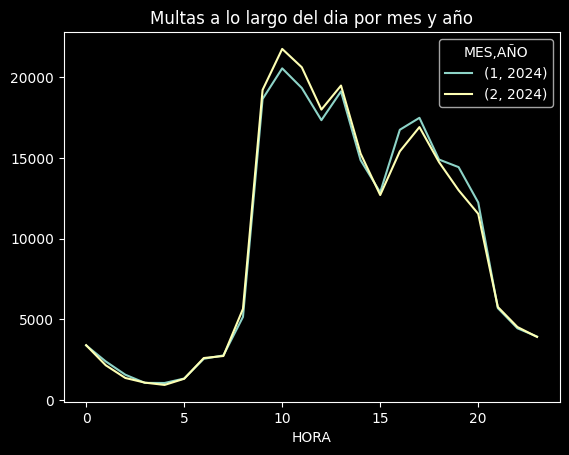

In [28]:
mf.fines_hour("test_graphic")

And we can see the maximum and minimum possible amounts per month, taking discounts into account.

In [29]:
import numpy as np
mf.total_payment()


,,MAX_IMPORT,MIN_IMPORT
MES,ANIO,,
1,2024,30457320.0,15228660.0
2,2024,30251870.0,15125935.0
